# Análisis Geoespacial IPM - Zona de Intervención: Roosevelt

Este notebook prioriza la visualización cartográfica de las 5 variables más relevantes del Índice de Pobreza Multidimensional (IPM) en el corredor Roosevelt (Buffer 100m).

### Contexto y Cifras Generales (Corte Mayo 2026)

Para la interpretación de los resultados, se deben considerar dos lógicas opuestas:
1. **Índice de Condición Social (ICS):** Es un indicador directo; un valor del **100% representa el escenario óptimo** (bienestar y acceso pleno).
2. **Índice de Pobreza Multidimensional (IPM):** Es un indicador inverso; un valor del **100% representa el escenario crítico** (pobreza absoluta).

A nivel distrital, Cali presenta una marcada brecha territorial. La **severidad de la pobreza (IPM promedio en manzanas con incidencia > 0)** es del **15.28% en el área urbana**, mientras que en el **área rural se dispara al 38.33%**, impulsada principalmente por carencias en infraestructura básica en los corregimientos.

Este análisis se enfoca en el corredor Roosevelt para identificar las privaciones específicas que afectan a este territorio de intervención.

In [9]:
# 1. Instalación de dependencias (solo en Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install geopandas matplotlib seaborn openpyxl -q

In [10]:
# 2. Importar librerías
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches

sns.set_style('white')
print('Librerías listas')

Librerías listas


In [11]:
# 3. Definir rutas con detección de entorno
REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if 'google.colab' in sys.modules:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    else:
        !cd {REPO_DIR} && git pull
    BASE_DIR = REPO_DIR
else:
    if os.path.exists('indice_Pobreza'): BASE_DIR = '.'
    elif os.path.exists('../indice_Pobreza'): BASE_DIR = '..'
    elif os.path.exists('../../indice_Pobreza'): BASE_DIR = '../..'
    else: BASE_DIR = '.'

DATA_BASE = os.path.join(BASE_DIR, 'indice_Pobreza/data')

# Capas
PATH_IPM_VARS_FULL = os.path.join(DATA_BASE, 'geojson_ipm/Mzn_ipm_variables.geojson')
PATH_MANZANAS_FONDO = os.path.join(DATA_BASE, 'geojson_Manzanas_catastrales/geojson_Manzanas_catastrales.geojson')
PATH_AREA_ESTUDIO = os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_Roosevelt_Buffer_100.geojson')

# Cargar datos
gdf_full = gpd.read_file(PATH_IPM_VARS_FULL)
gdf_fondo = gpd.read_file(PATH_MANZANAS_FONDO)
gdf_area = gpd.read_file(PATH_AREA_ESTUDIO)

# Unificar CRS a WGS84
gdf_full = gdf_full.to_crs('EPSG:4326')
gdf_fondo = gdf_fondo.to_crs('EPSG:4326')
gdf_area = gdf_area.to_crs('EPSG:4326')

# Filtrado espacial preciso (Centroide dentro del Buffer)
gdf_p = gdf_full.to_crs("EPSG:3115")
area_p = gdf_area.to_crs("EPSG:3115")
idx = gpd.sjoin(gdf_p.copy().assign(geometry=gdf_p.centroid), area_p[['geometry']], how='inner', predicate='within').index
gdf = gdf_full.loc[idx].copy()

print(f'Manzanas detectadas en Roosevelt: {len(gdf)}')

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.99 KiB | 1019.00 KiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   335f3be..877bf3a  main       -> origin/main
Updating 335f3be..877bf3a
Fast-forward
 .../notebooks_py/04_mapeo_ipm_roosevelt.ipynb      | 171 ++++++++-------------
 1 file changed, 68 insertions(+), 103 deletions(-)
Manzanas detectadas en Roosevelt: 40


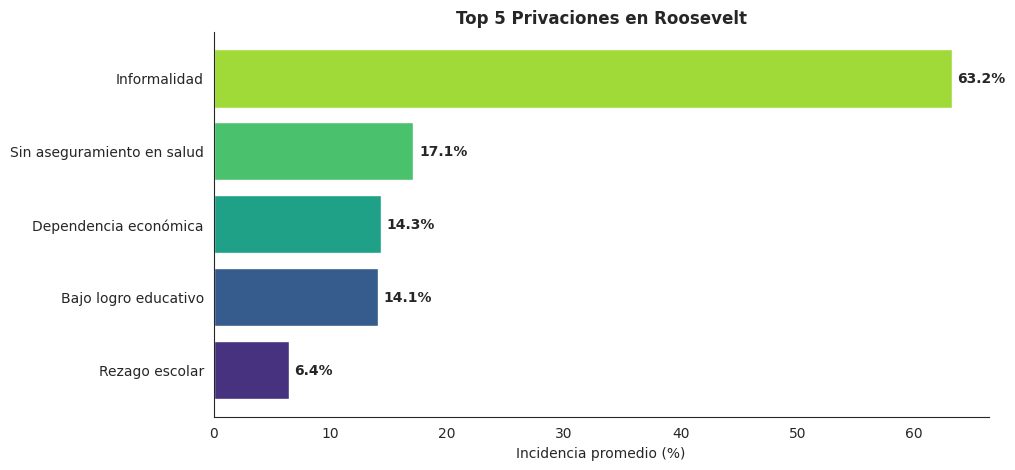

In [12]:
# 4. Escalas Maestras Notebook 01 (Comparabilidad Distrital)
RANGOS_IPM_8 = [
    (0.4, 20.0, "0.4% - 20.0%"),
    (20.1, 27.0, "20.1% - 27.0%"),
    (27.1, 33.1, "27.1% - 33.1%"),
    (33.2, 39.8, "33.2% - 39.8%"),
    (39.9, 48.6, "39.9% - 48.6%"),
    (48.7, 60.6, "48.7% - 60.6%"),
    (60.7, 80.0, "60.7% - 80.0%"),
    (80.1, 100.0, "80.1% - 100.0%"),
]

# Usamos Viridis para variables IPM segun mandato de accesibilidad
cmap_master = plt.get_cmap("viridis", 8)
COLORES_IPM_8 = [mcolors.to_hex(cmap_master(i)) for i in range(8)]
CATEGORIAS_IPM_8 = ["Bajo", "Moderado-Bajo", "Moderado", "Moderado-Alto", "Alto", "Muy Alto", "Extremo", "Extremo Maximo"]

def _clasificar_ipm_master(gdf_zone, columna):
    datos = gdf_zone[columna].astype(float)
    cortes = [r[0] for r in RANGOS_IPM_8] + [RANGOS_IPM_8[-1][1]]
    etiquetas = [r[2] for r in RANGOS_IPM_8]
    res = gdf_zone.copy()
    res["_rango"] = pd.cut(datos, bins=cortes, labels=etiquetas, include_lowest=True, duplicates="drop")
    col_map = dict(zip(etiquetas, COLORES_IPM_8))
    res["_color"] = res["_rango"].astype(str).map(col_map).fillna("#BDBDBD")
    return res

COLS_MAP = {
    'ANALF_': 'Analfabetismo', 'BAJO_': 'Bajo logro educativo', 
    'INFANCIA_': 'Barreras primera infancia', 'INASIS_': 'Inasistencia escolar', 
    'REZAGO_': 'Rezago escolar', 'TRAB_INFAN': 'Trabajo infantil', 
    'DEPEN_': 'Dependencia económica', 'INFOR_': 'Informalidad', 
    'SALUD_': 'Barreras de salud', 'ASEGU_': 'Sin aseguramiento en salud', 
    'HACI_': 'Hacinamiento crítico', 'PARED_': 'Paredes precarias', 
    'EXCRE_': 'Eliminación inadecuada de excretas', 'PISOS_': 'Pisos precarios', 
    'AGUA_': 'Sin acceso a agua mejorada'
}

top_5 = gdf[list(COLS_MAP.keys())].mean().sort_values(ascending=False).head(5).index.tolist()

# Visualizacion Ranking Top 5
top_means = gdf[top_5].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 5))
plt.barh([COLS_MAP[c] for c in top_means.index], top_means.values, color=cmap_master(np.linspace(0.2, 0.8, 5)))
for i, v in enumerate(top_means.values): plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')
plt.title("Top 5 Privaciones en Roosevelt", fontweight='bold')
plt.xlabel("Incidencia promedio (%)")
sns.despine()
plt.show()

In [13]:
# 5. Motor de Mapeo Maestro (Sincronización Total Colab 1)
def plot_ipm_variable_master(gdf_zone, gdf_back, gdf_poly, column, title):
    fig, ax = plt.subplots(1, 1, figsize=(18, 12))

    # --- 1. Capa Base (Cubre todo el lienzo) ---
    gdf_back.plot(ax=ax, color="#F8F8F8", edgecolor="#DCDCDC", linewidth=0.1, alpha=0.8, zorder=1)

    # --- 2. Clasificación Maestra ---
    gdf_cl = _clasificar_ipm_master(gdf_zone, column)

    # --- 3. Ploteo de Manzanas y Borde ---
    gdf_cl.plot(ax=ax, color=gdf_cl["_color"], edgecolor="white", linewidth=0.35, zorder=3, alpha=0.9)
    gdf_poly.boundary.plot(ax=ax, color="#D55E00", linewidth=1.5, linestyle="-", alpha=0.8, zorder=2)

    # --- 4. Etiquetas de Datos (Contraste Maestro) ---
    for _, fila in gdf_cl.iterrows():
        if pd.isna(fila[column]): continue
        punto = fila.geometry.representative_point()
        valor = float(fila[column])
        txt_color = "white" if valor > 0 else "black"
        stk_color = "black" if valor > 0 else "white"
        ax.text(punto.x, punto.y, f"{valor:.1f}", fontsize=7, ha="center", va="center", fontweight="bold",
                color=txt_color, path_effects=[withStroke(linewidth=1.5, foreground=stk_color, alpha=0.8)], zorder=5)

    # --- 5. Ajuste de Vista 'Efecto Atlas' ---
    minx, miny, maxx, maxy = gdf_cl.total_bounds
    rx, ry = maxx - minx, maxy - miny
    ax.set_xlim(minx - rx*0.15, maxx + rx*0.75) # Expansión 75% derecha
    ax.set_ylim(miny - ry*0.15, maxy + ry*0.15)

    # --- 6. Leyenda Maestra ---
    handles = [mpatches.Patch(facecolor=COLORES_IPM_8[i], edgecolor="white", label=f"{RANGOS_IPM_8[i][2]} | {CATEGORIAS_IPM_8[i]}") for i in range(8)]
    handles.append(mpatches.Patch(facecolor="none", edgecolor="#D55E00", linewidth=1.5, label="Area de estudio"))
    
    ax.legend(handles=handles, title=f"Privación: {title.upper()}\nRango % | Categoría",
              loc="center right", frameon=True, framealpha=0.9, fontsize=9, title_fontsize=11)
    
    ax.set_title(f"IPM por manzana: {title.upper()} - Roosevelt", fontsize=16, fontweight="bold", pad=20)
    ax.set_axis_off()
    plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.01)
    plt.show()

Generando mapas sincronizados con el Estándar Maestro del Notebook 01...


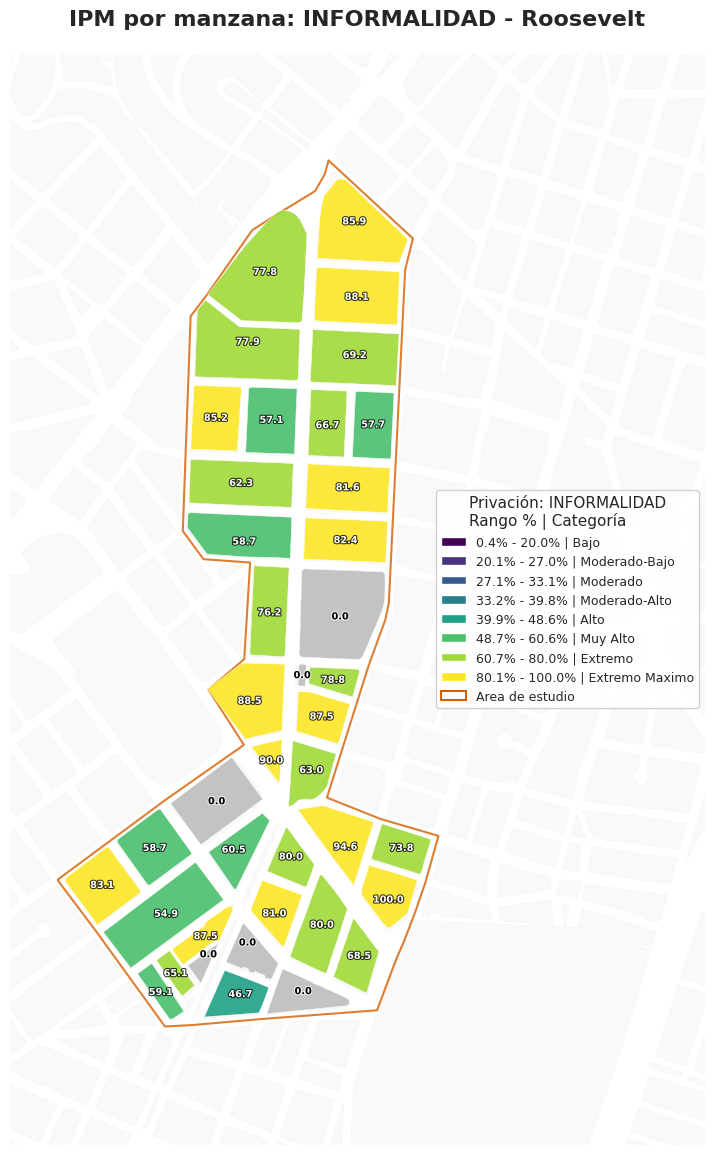

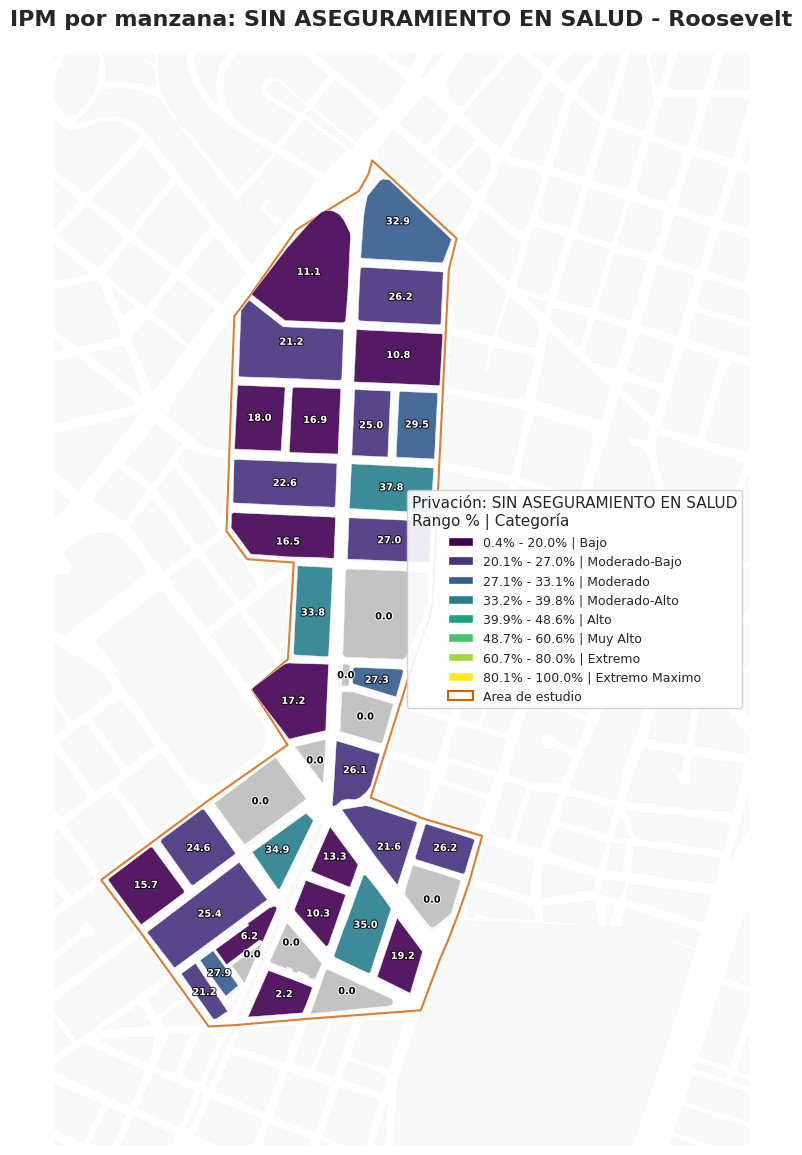

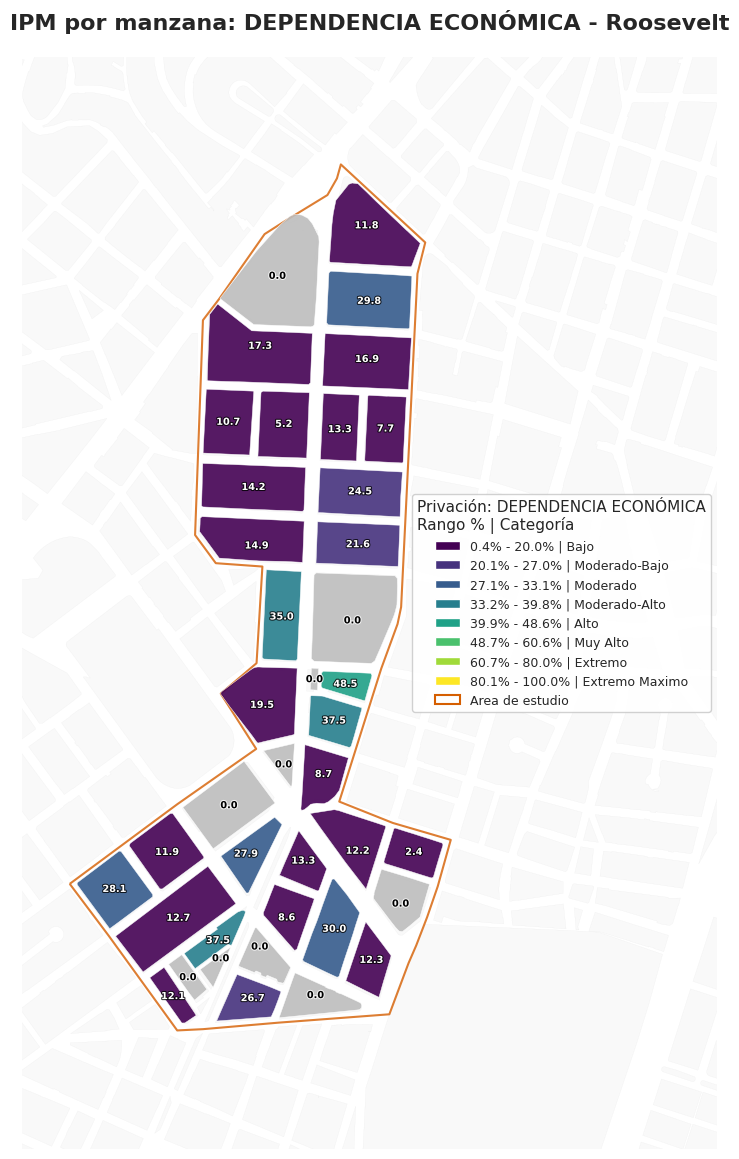

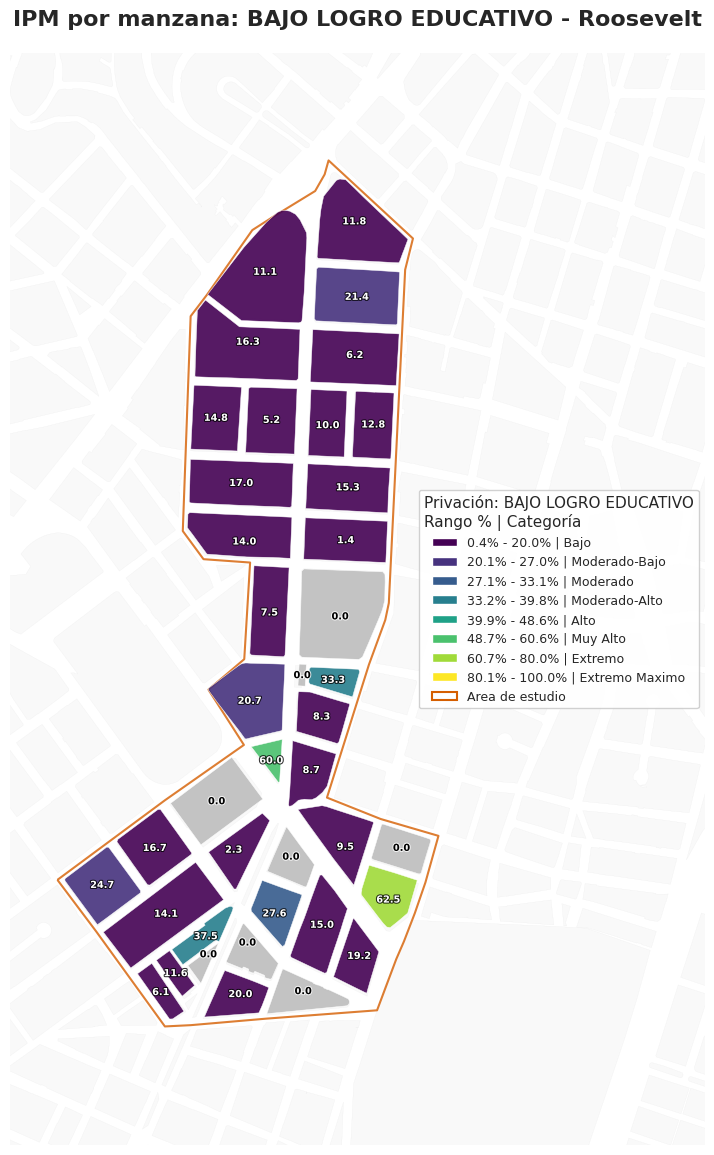

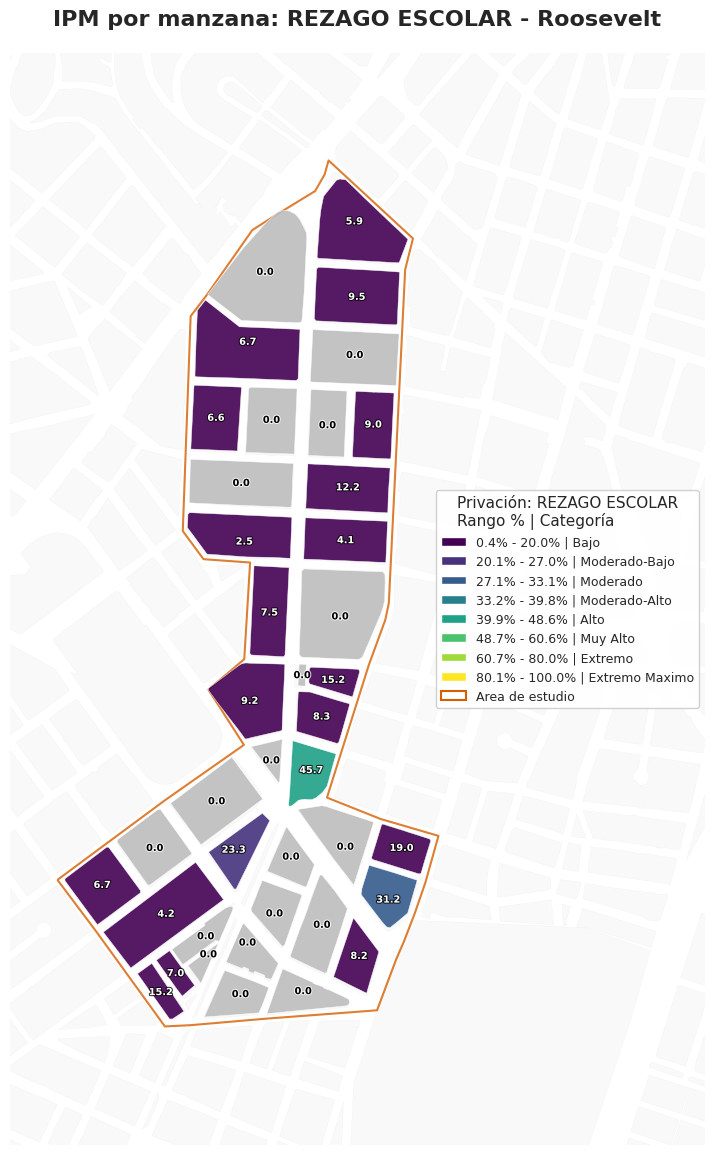

In [14]:
# 6. Ejecución de la Cartografía Maestra
print("Generando mapas sincronizados con el Estándar Maestro del Notebook 01...")
for var in top_5:
    plot_ipm_variable_master(gdf, gdf_fondo, gdf_area, var, COLS_MAP[var])

## 7. Validación de Estándares Técnicos
Este notebook cumple con las directrices de geo-informática de Santiago de Cali (Mayo 2026) y sincronización con el Notebook 01:
1. **Accesibilidad:** Uso de la paleta **Viridis** aplicada a la escala global IPM.
2. **Comparabilidad:** Uso de los **8 rangos distritales** definidos en el Colab 1.
3. **Efecto Atlas:** Manzanas de contexto (#F8F8F8) cubriendo todo el lienzo.
4. **Contraste:** Etiquetas inteligentes (Blanco/Negro) con stroke de 1.5.
5. **Layout:** Expansión del 75% a la derecha para leyenda integrada.
6. **Precisión:** Datos ajustados a **1 decimal**.